
# **Linear Regression on the Wine Quality Dataset**

In this notebook we implement and explore **linear regression** using our implementation from the `rice_ml` package.

We will:

- Load the **Red Wine Quality** dataset from the UCI repository
- Perform basic **exploratory data analysis (EDA)**
- Preprocess the data with our own utilities
- Train a **LinearRegression** model (normal equation)
- Evaluate using regression metrics
- Visualize predictions and residuals



---

## 1. Environment & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.pre_processing import standardize, train_test_split
from rice_ml.processing.post_processing import r2_score
from rice_ml.supervised_learning.linear_regression import LinearRegression



---

## 2. Load the Red Wine Quality Dataset

We use the **Red Wine Quality** dataset from the UCI Machine Learning Repository. This dataset contains physicochemical properties of red *Vinho Verde* wine samples from Portugal, along with a quality rating.

The dataset has:

- **11 numeric input features** describing the chemical properties of the wine
- **1 target**: quality score (`quality`) — an integer between 0 and 10 assigned by wine experts

We treat quality as a **continuous regression target**.

### Feature Summary

All features in the Wine Quality dataset are numeric and continuous.

| Feature | Type | Description |
|---------|------|-------------|
| fixed acidity | Continuous | Tartaric acid concentration (g/dm³) |
| volatile acidity | Continuous | Acetic acid concentration — high levels produce vinegar taste |
| citric acid | Continuous | Adds freshness and flavor (g/dm³) |
| residual sugar | Continuous | Sugar remaining after fermentation (g/dm³) |
| chlorides | Continuous | Salt concentration in wine (g/dm³) |
| free sulfur dioxide | Continuous | Free form of SO₂ — prevents microbial growth |
| total sulfur dioxide | Continuous | Total SO₂ (free + bound) — high levels detectable in taste |
| density | Continuous | Density of wine relative to water (g/cm³) |
| pH | Continuous | Acidity on log scale (0–14) |
| sulphates | Continuous | Additive contributing to SO₂ levels |
| alcohol | Continuous | Alcohol percentage by volume |

No missing values are present in the dataset.

### Data Notes
- All features are continuous numerical variables
- No explicit NaN values are present
- Features vary significantly in scale, motivating standardization


In [3]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



---

## 3. Exploratory Data Analysis

We examine basic statistics, the distribution of the target variable, and correlations between features.


In [4]:

df.describe().round(3)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


In [5]:

print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Target Distribution — Wine Quality

The quality scores range from 3 to 8, with most wines rated 5 or 6.
This roughly normal distribution makes the regression well-posed.


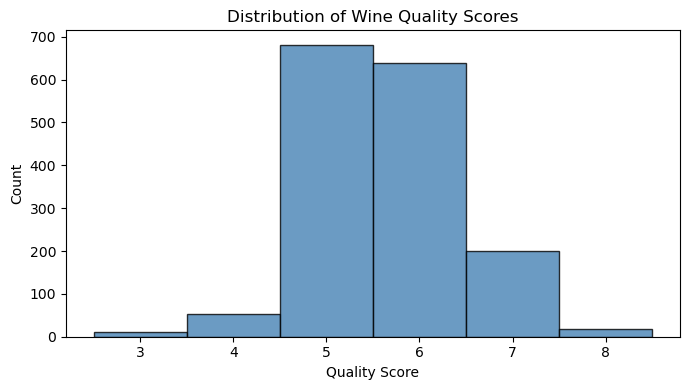

In [6]:

plt.figure(figsize=(7, 4))
plt.hist(df['quality'], bins=np.arange(2.5, 9.5, 1), edgecolor='black', color='steelblue', alpha=0.8)
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality Scores')
plt.xticks(range(3, 9))
plt.tight_layout()
plt.show()


### Correlation Matrix

Visualizing pairwise correlations helps identify which features may be most predictive of quality.
Strong positive correlation with `alcohol`; strong negative correlation with `volatile acidity` are expected.


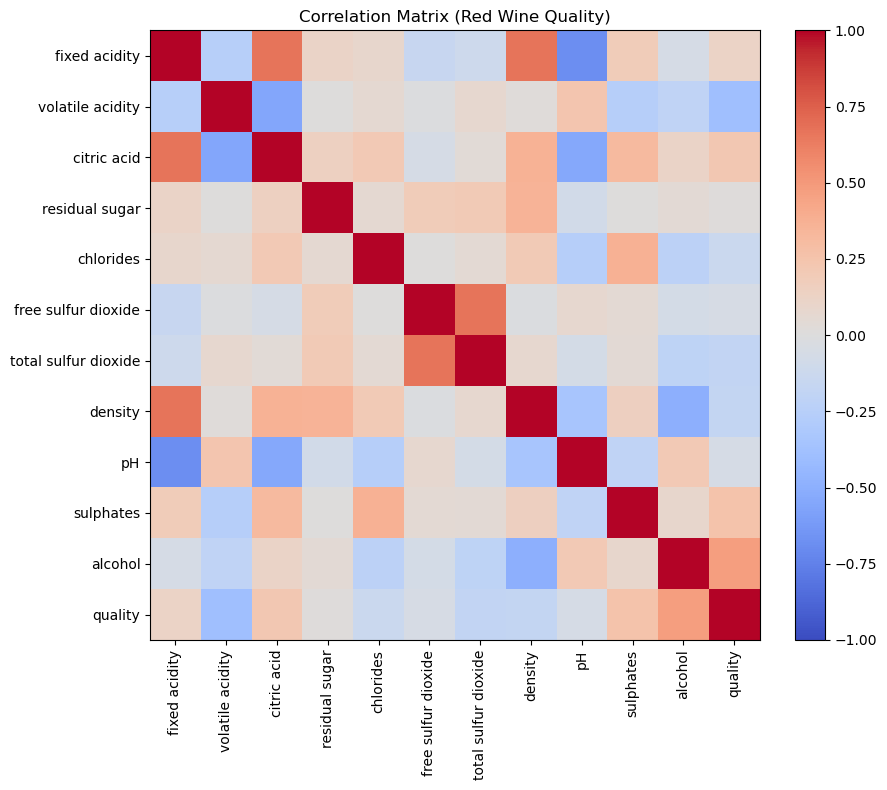

In [7]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(ticks=np.arange(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr.columns)), labels=corr.columns)
plt.title('Correlation Matrix (Red Wine Quality)')
plt.tight_layout()
plt.show()


### Feature–Target Correlations

We isolate which features correlate most strongly with the quality target.


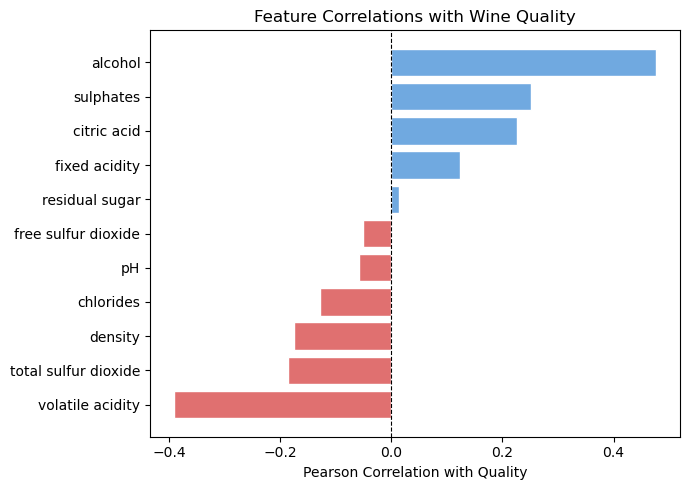

In [8]:

target_corr = corr['quality'].drop('quality').sort_values()

plt.figure(figsize=(7, 5))
colors = ['#E07070' if v < 0 else '#70A9E0' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Pearson Correlation with Quality')
plt.title('Feature Correlations with Wine Quality')
plt.tight_layout()
plt.show()



---

## 4. Preprocessing

We separate the dataset into:

- Features matrix $X \in \mathbb{R}^{n \times d}$
- Target vector $y \in \mathbb{R}^{n}$

Then we apply **standardization** to the features:

$$X_{\text{std}} = \frac{X - \mu}{\sigma}$$

This centers each feature to zero mean and unit variance, which improves numerical stability for optimization.

We use `rice_ml.processing.preprocessing.standardize` and `train_test_split`.


In [9]:

feature_cols = [c for c in df.columns if c != 'quality']
X = df[feature_cols].values
y = df['quality'].values

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features: {feature_cols}")


X shape : (1599, 11)
y shape : (1599,)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [10]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")


Train size : 1280 samples
Test size  : 319 samples


In [12]:
X_train_s = standardize(X_train)
X_test_s = standardize(X_test)

print("Before standardization — first feature stats on training set:")
print(f"  mean = {X_train[:, 0].mean():.4f},  std = {X_train[:, 0].std():.4f}")
print("After standardization:")
print(f"  mean = {X_train_s[:, 0].mean():.4f},  std = {X_train_s[:, 0].std():.4f}")


Before standardization — first feature stats on training set:
  mean = 8.3322,  std = 1.7190
After standardization:
  mean = 0.0000,  std = 1.0000



---

## 5. Mathematical Background — Linear Regression

**Linear regression** models the target as a linear combination of features:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

The closed-form **normal equation** finds the optimal weights in one step:

$$\hat{\mathbf{w}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

This minimizes the **mean squared error (MSE)**:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

### Evaluation Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| $R^2$ | $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$ | Fraction of variance explained (1 = perfect) |
| MSE | $\frac{1}{n}\sum(y - \hat{y})^2$ | Mean squared prediction error |
| RMSE | $\sqrt{\text{MSE}}$ | In original units |
| MAE | $\frac{1}{n}\sum|y - \hat{y}|$ | Mean absolute error |



---

## 6. Train the Model


In [15]:

linreg = LinearRegression()
linreg.fit(X_train_s, y_train)

print("Model trained successfully!")
print(f"Intercept    : {linreg.intercept_:.6f}")
print(f"Coefficients : {linreg.coef_}")


Model trained successfully!
Intercept    : 5.657813
Coefficients : [ 0.11441501 -0.19758405 -0.06218907  0.0281251  -0.06849317  0.04503478
 -0.10190173 -0.07332182 -0.01935115  0.14880773  0.28913336]



---

## 7. Evaluate on Training & Test Sets


In [16]:

y_train_pred = linreg.predict(X_train_s)
y_test_pred  = linreg.predict(X_test_s)

def mse(y_true, y_pred):  return np.mean((y_true - y_pred) ** 2)
def rmse(y_true, y_pred): return np.sqrt(mse(y_true, y_pred))
def mae(y_true, y_pred):  return np.mean(np.abs(y_true - y_pred))

r2_train  = r2_score(y_train, y_train_pred)
mse_train = mse(y_train, y_train_pred)

r2_test  = r2_score(y_test, y_test_pred)
mse_test = mse(y_test, y_test_pred)

print("=" * 40)
print(" TRAINING SET")
print("=" * 40)
print(f"  R² Score : {r2_train:.4f}")
print(f"  MSE      : {mse_train:.4f}")
print(f"  RMSE     : {rmse(y_train, y_train_pred):.4f}")
print(f"  MAE      : {mae(y_train, y_train_pred):.4f}")
print()
print("=" * 40)
print(" TEST SET")
print("=" * 40)
print(f"  R² Score : {r2_test:.4f}")
print(f"  MSE      : {mse_test:.4f}")
print(f"  RMSE     : {rmse(y_test, y_test_pred):.4f}")
print(f"  MAE      : {mae(y_test, y_test_pred):.4f}")


 TRAINING SET
  R² Score : 0.3643
  MSE      : 0.4222
  RMSE     : 0.6498
  MAE      : 0.5068

 TEST SET
  R² Score : 0.3113
  MSE      : 0.4080
  RMSE     : 0.6388
  MAE      : 0.4882



---

## 8. Visualizations

### Predicted vs Actual

If the model were perfect, all points would lie on the diagonal $y = \hat{y}$.


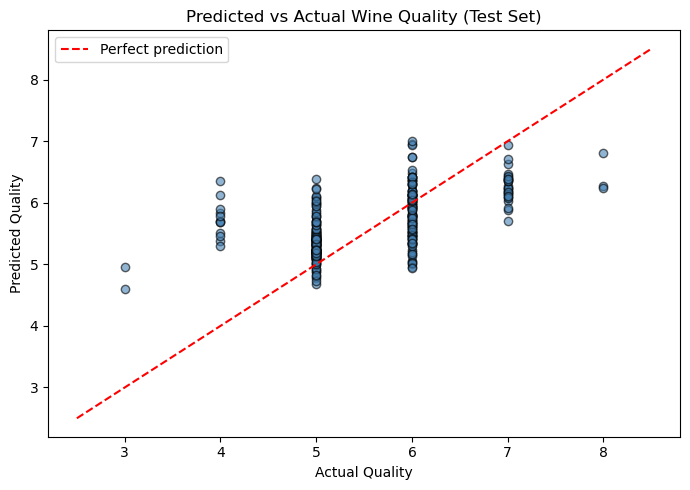

In [17]:

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor='k', color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()) - 0.5,
        max(y_test.max(), y_test_pred.max()) + 0.5]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.title('Predicted vs Actual Wine Quality (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()


The scatter plot shows the model captures the general trend — higher actual quality corresponds to higher predicted quality — though predictions are smoothed toward the mean, which is typical of linear regression on an ordinal target.


### Feature Coefficient Plot

The magnitude of each standardized coefficient indicates its relative influence on the predicted quality.


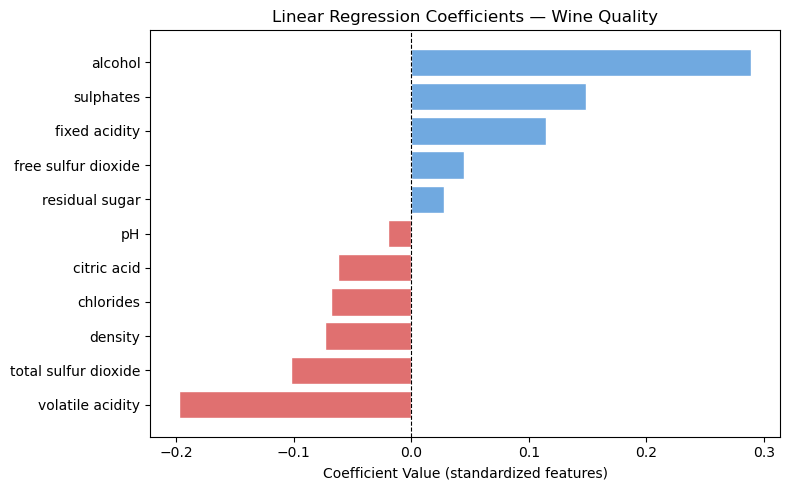

In [19]:
coef = np.array(linreg.coef_).flatten()
coef_series = pd.Series(coef, index=feature_cols).sort_values()

plt.figure(figsize=(8, 5))
bar_colors = ['#E07070' if v < 0 else '#70A9E0' for v in coef_series.values]
plt.barh(coef_series.index, coef_series.values, color=bar_colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value (standardized features)')
plt.title('Linear Regression Coefficients — Wine Quality')
plt.tight_layout()
plt.show()


### Residuals vs Predicted


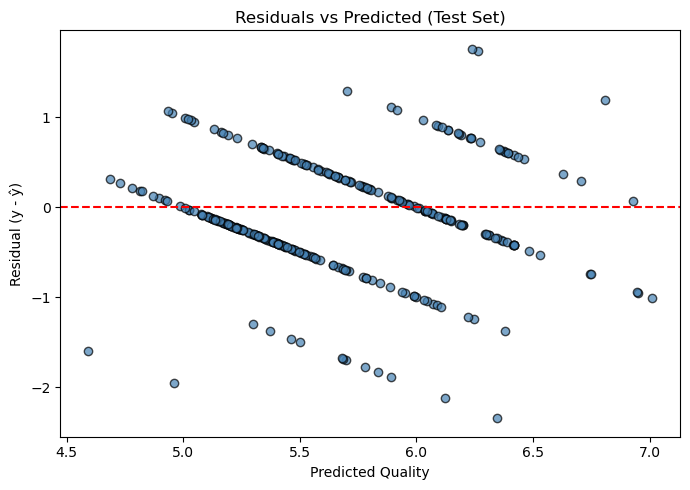

In [20]:

residuals = y_test - y_test_pred

plt.figure(figsize=(7, 5))
plt.scatter(y_test_pred, residuals, alpha=0.7, edgecolor='k', color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Quality')
plt.ylabel('Residual (y - ŷ)')
plt.title('Residuals vs Predicted (Test Set)')
plt.tight_layout()
plt.show()


The residual plot shows that residuals are approximately centered around
zero with no strong systematic pattern. This suggests the linear model
captures the main trends in the data reasonably well.

The banding pattern (residuals cluster in integer steps) arises because
the true quality scores are discrete integers while the model produces
continuous predictions — this is a fundamental limitation of applying
linear regression to an ordinal target.


### Residual Distribution


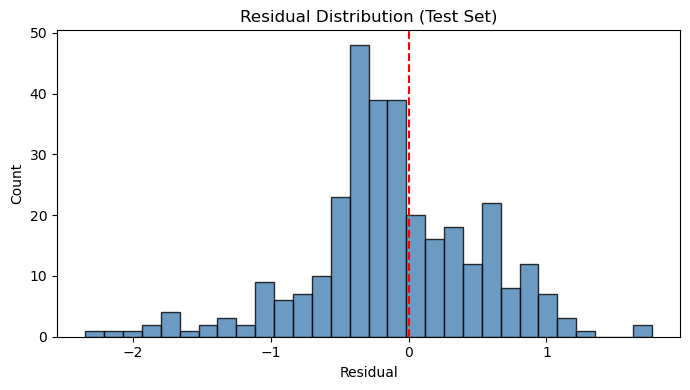

In [21]:

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residual Distribution (Test Set)')
plt.tight_layout()
plt.show()



---

## 9. Model Summary

We print a full summary using the `summary` method from `rice_ml`.


In [22]:

linreg.summary(X_test_s, y_test)


Linear Regression Summary
----------------------------------------
Intercept: 5.657812500000084
Coefficients: [ 0.11441501 -0.19758405 -0.06218907  0.0281251  -0.06849317  0.04503478
 -0.10190173 -0.07332182 -0.01935115  0.14880773  0.28913336]
R² Score: 0.3113
MSE: 0.4080
RMSE: 0.6388
MAE: 0.4882
----------------------------------------


### Model Limitations

Linear regression assumes a linear relationship between features and the
target variable. While the model captures the main trends, the Wine Quality
dataset contains nonlinear relationships and interactions (e.g., between
alcohol and acidity) that a linear model cannot fully represent.

Additionally, the quality score is an **ordinal integer** (3–8), not a
true continuous variable. Ordinal classification models or regression
trees may capture this structure more faithfully.



---

## 10. Conclusion

In this notebook, we:

- Loaded the **Red Wine Quality** dataset from UCI
- Explored basic statistics, the quality distribution, and feature correlations
- Standardized features and split data into train/test sets using `rice_ml.processing.preprocessing`
- Trained a **custom LinearRegression** model (normal equation) from `rice_ml.supervised_learning`
- Evaluated performance via $R^2$, MSE, RMSE, and MAE using `rice_ml.processing.post_processing`
- Visualized predictions, coefficient magnitudes, and residuals


